In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline     

from sklearn.linear_model import LinearRegression
import pandas as pd

from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.rpcmci import RPCMCI
from tigramite.data_processing import DataFrame

from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

from gridsearch import RegimeAICSelector

# Simulated time series data

### Regime 0

- $X^0_t = f(X^0_{t-1}, X^1_{t-1})$
- $X^1_t = f(X^1_{t-1}, X^2_{t-1})$
- $X^2_t = f(X^2_{t-1}, X^0_{t-1})$
- $X^3_t = f(X^3_{t-1})$


### Regime 1

- $X^0_t = f(X^0_{t-1}, X^2_{t-1})$
- $X^1_t = f(X^1_{t-1})$
- $X^2_t = f(X^2_{t-1}, X^1_{t-1})$
- $X^3_t = f(X^3_{t-1}, X^2_{t-1})$


In [ ]:
# Set seed for reproducibility
np.random.seed(42)

# Time settings
T = 700
num_vars = 4
var_names = [r'$X^0$', r'$X^1$', r'$X^2$', r'$X^3$']
data = np.random.randn(T, num_vars)
regimes = np.zeros(T, dtype=int)

# Define regime periods
regime_0_intervals = [(0, 100), (301, 600)]
regime_1_intervals = [(101, 300), (601, 699)]

# Mark regimes
for start, end in regime_0_intervals:
    regimes[start:end + 1] = 0
for start, end in regime_1_intervals:
    regimes[start:end + 1] = 1

# Simulate data based on structural equations
for t in range(1, T):
    if regimes[t] == 0:
        # Regime 0 
        data[t, 0] += 0.4 * data[t - 1, 0] + 0.3 * data[t - 1, 1]  # X0_t = f(X0_{t-1}, X1_{t-1})
        data[t, 1] += 0.4 * data[t - 1, 1] + 0.3 * data[t - 1, 2]  # X1_t = f(X1_{t-1}, X2_{t-1})
        data[t, 2] += 0.4 * data[t - 1, 2] + 0.3 * data[t - 1, 0]  # X2_t = f(X2_{t-1}, X0_{t-1})
        data[t, 3] += 0.5 * data[t - 1, 3]                         # X3_t = f(X3_{t-1})
    else:
        # Regime 1
        data[t, 0] += 0.4 * data[t - 1, 0] + 0.3 * data[t - 1, 2]  # X0_t = f(X0_{t-1}, X2_{t-1})
        data[t, 1] += 0.4 * data[t - 1, 1]                         # X1_t = f(X1_{t-1})
        data[t, 2] += 0.4 * data[t - 1, 2] + 0.3 * data[t - 1, 1]  # X2_t = f(X2_{t-1}, X1_{t-1}) X2_t = 0.4*X2_t-1 + 0.6*X1_t-1
        data[t, 3] += 0.4 * data[t - 1, 3] + 0.3 * data[t - 1, 2]  # X3_t = f(X3_{t-1}, X2_{t-1})

# Convert to DataFrame
df = pd.DataFrame(data, columns=[f"X{i}" for i in range(num_vars)])
df["regime"] = regimes

# Generate time index
datatime = np.arange(T)

In [100]:
df

,X0,X1,X2,X3,regime
0,0.496714,-0.138264,0.647689,1.523030,0
1,-0.076947,-0.095136,1.987302,1.528950,0
2,-0.528794,1.100696,0.308419,0.298745,0
3,0.360654,-1.380476,-1.760188,-0.412915,0
4,-1.282712,-0.766000,-1.503903,-1.618761,0
...,...,...,...,...,...
695,0.407991,-0.997473,-1.771363,-1.251127,1
696,-0.855416,-0.750910,-1.777783,-2.327977,1
697,-1.331622,-0.118938,-0.341357,-2.021949,1
698,-1.048054,-0.974273,-0.203663,-1.759615,1


In [101]:
train_data = data[:500]

In [105]:
selector = RegimeAICSelector(
    data=train_data, 
    tau_max=1,
    switch_thres=1e-3,
    num_iterations=10,
    max_anneal=15,
    pc_alpha=0.2,
    alpha_level=0.01,
    n_jobs=-1,
    cond_ind_test=ParCorr(),
    prediction_model=LinearRegression(),
    verbosity=-2
)

results = selector.find_best(grid_NK=range(2,4), grid_NC=range(1,4))
print("Done Grid Search for NK and NC!")


################# Annealing iteration a = 0 ####################


###### Optimization step q = 0
################ Regime k = 0

################# Annealing iteration a = 1 ####################


###### Optimization step q = 0
################ Regime k = 0

################# Annealing iteration a = 2 ####################


###### Optimization step q = 0
################ Regime k = 0

################# Annealing iteration a = 3 ####################


###### Optimization step q = 0
################ Regime k = 0
################ Regime k = 1
################ Regime k = 1
################ Regime k = 1
################ Regime k = 1

Optimal objective: reached.
Difference in abs value between the previous and current gamma (shape num_regimesxT) : 489.89182772995116

###### Optimization step q = 1
################ Regime k = 0
################ Regime k = 1
*****Regime with too few samples in annealing a = 2 at iteration q = 1.*****

***** Break k-loop of regimes *****
 
***** Break q-loop of

In [106]:
results['all_results']

{(2, 1): {'aicc': 6369.689129907569, 'n_params': 17},
 (2, 2): {'aicc': 5648.750852488265, 'n_params': 16},
 (2, 3): {'aicc': 5750.304244220226, 'n_params': 14},
 (3, 1): {'aicc': inf, 'n_params': None},
 (3, 2): {'aicc': inf, 'n_params': None},
 (3, 3): {'aicc': inf, 'n_params': None}}

In [107]:
results['best']

{'aicc': 5648.750852488265, 'NK': 2, 'NC': 2}

In [108]:
NK = results['best']['NK']
NC = results['best']['NC']

In [109]:
# only include the first 500 time points (200 for testing set)
dataframe = pp.DataFrame(data[:500])

rpcmci = RPCMCI(dataframe=dataframe, 
                cond_ind_test=ParCorr(),
                prediction_model=LinearRegression(),
                verbosity= -2)


# RPCMCI parameters
num_regimes = NK
max_transitions = NC
switch_thres = 1e-3
num_iterations = 10
max_anneal = 15
tau_min = 1
tau_max = 1
pc_alpha = 0.2
alpha_level = 0.01
n_jobs = -1     

# Run RPCMCI
results = rpcmci.run_rpcmci(
    num_regimes=num_regimes, max_transitions=max_transitions, 
    switch_thres=switch_thres, 
    num_iterations=num_iterations, max_anneal=max_anneal, 

    tau_min=tau_min, tau_max=tau_max,
    pc_alpha=pc_alpha, alpha_level=alpha_level, 
    n_jobs=n_jobs
    )

if results is None:
    print("All annealings resulted in errors. Increase annealing and tune other parameters!")
else:
    print("Done!")


################# Annealing iteration a = 0 ####################


###### Optimization step q = 0
################ Regime k = 0

################# Annealing iteration a = 1 ####################


###### Optimization step q = 0
################ Regime k = 0

################# Annealing iteration a = 2 ####################


###### Optimization step q = 0
################ Regime k = 0

################# Annealing iteration a = 3 ####################


###### Optimization step q = 0
################ Regime k = 0
################ Regime k = 1
################ Regime k = 1
################ Regime k = 1
################ Regime k = 1

Optimal objective: reached.
Difference in abs value between the previous and current gamma (shape num_regimesxT) : 489.09464909946456

###### Optimization step q = 1
################ Regime k = 0
################ Regime k = 1
*****Regime with too few samples in annealing a = 0 at iteration q = 1.*****

***** Break k-loop of regimes *****
 
***** Break q-loop of

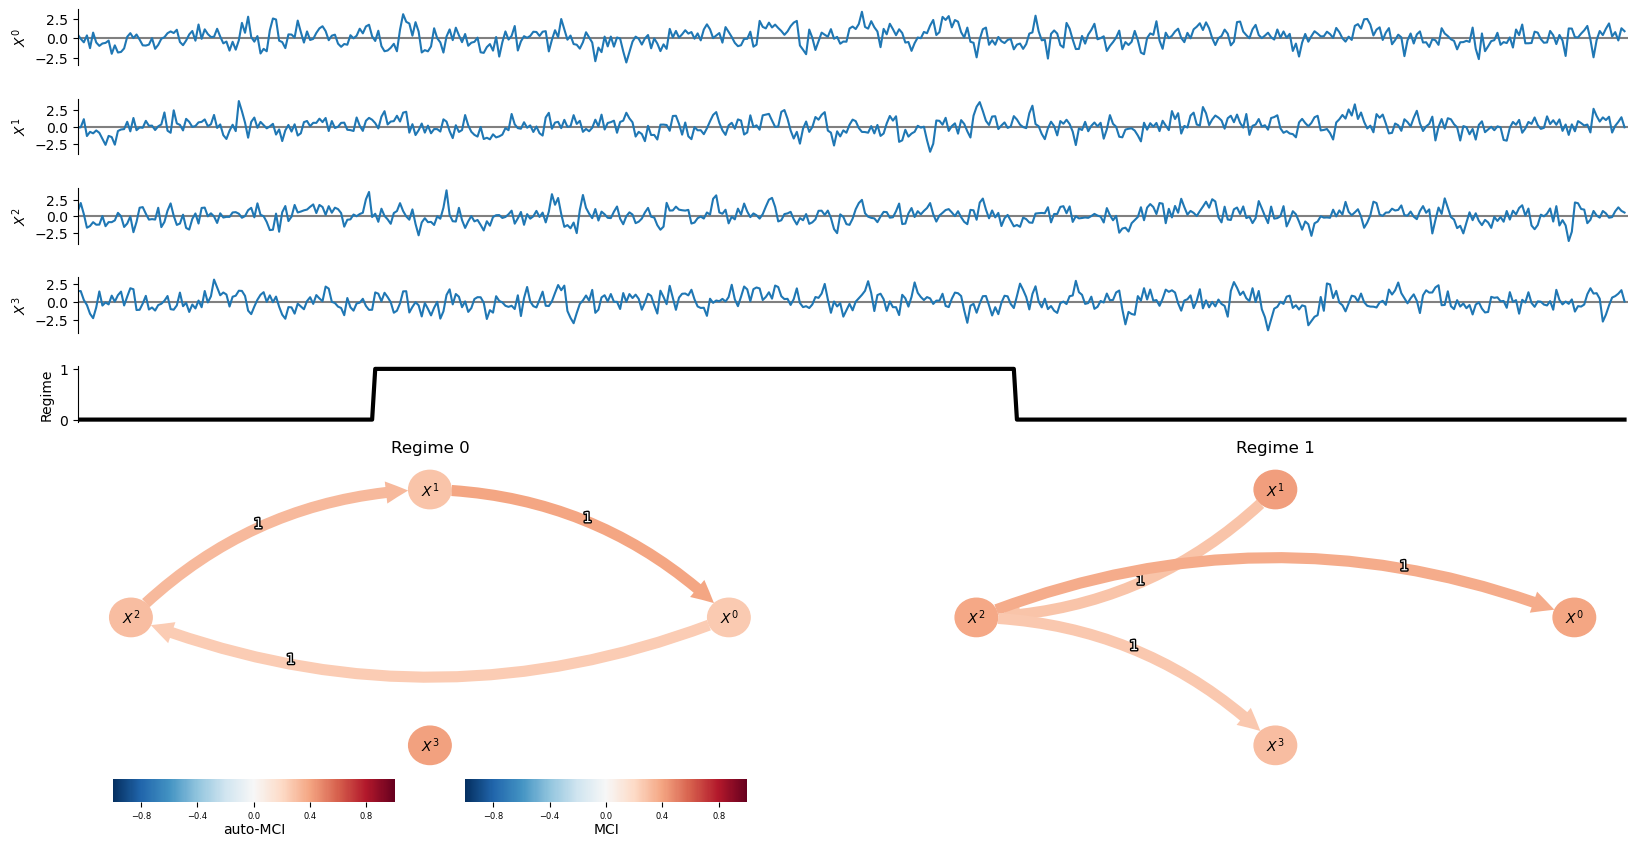

In [110]:
regimes = results['regimes'].argmax(axis=0)
n_regimes = len(results['causal_results'])

T = 500
datatime = datatime[:T]
temp = df.drop(columns=['regime'])
data = temp[:T].to_numpy()
N = len(temp.columns)


# Create nice Mosaic plot
mosaic = [['data %s' %j for i in range(n_regimes)] for j in range(N+1)]
for n in range(N):
    mosaic.append(['graph %s' %i for i in range(n_regimes)])

fig, axs = plt.subplot_mosaic(mosaic = mosaic, figsize=(20, 10))

for j in range(N):
    ax = axs['data %s' %j]
    ax.axhline(0., color='grey')
    ax.plot(datatime, data[:,j])
    for loc, spine in ax.spines.items():
        if loc != 'left':
            spine.set_color("none")
    
    ax.xaxis.set_ticks([])   
    ax.set_xlim(0., T)
    ax.set_ylabel(var_names[j])
    
# Regime variable
ax = axs['data %s' %N]
ax.plot(datatime, regimes.astype('int'), lw=3, color='black')
for loc, spine in ax.spines.items():
    if loc != 'left':
        spine.set_color("none")
ax.xaxis.set_ticks([]) 
ax.yaxis.set_ticks(range(n_regimes))   
ax.set_xlim(0., T)
ax.set_ylabel("Regime")
    
# Causal graphs for each regime
for w in range(n_regimes):
    if w == 0: show_colorbar=True
    else: show_colorbar = False
    tp.plot_graph(graph=results['causal_results'][w]['graph'], 
                  val_matrix=results['causal_results'][w]['val_matrix'], 
                  show_colorbar=show_colorbar,
                  var_names=var_names,
                  fig_ax=(fig, axs['graph %s' %w]))
    axs['graph %s' %w].set_title("Regime %d" %w, pad=-4)

fig.subplots_adjust(hspace=0.6)
plt.show()

### Regime 0

- $X^0_t = f(X^0_{t-1}, X^1_{t-1})$
- $X^1_t = f(X^1_{t-1}, X^2_{t-1})$
- $X^2_t = f(X^2_{t-1}, X^0_{t-1})$
- $X^3_t = f(X^3_{t-1})$


### Regime 1

- $X^0_t = f(X^0_{t-1}, X^2_{t-1})$
- $X^1_t = f(X^1_{t-1})$
- $X^2_t = f(X^2_{t-1}, X^1_{t-1})$
- $X^3_t = f(X^3_{t-1}, X^2_{t-1})$

In [ ]:
# Define regime periods
#regime_0_intervals = [(0, 100), (301, 550)]
#regime_1_intervals = [(101, 300), (551, 699)]

In [115]:
#-- causal structures estimated with RPCMCI for each regime
causal_structures = {
    # Regime 0
    0: {
        "X0": [(0, -1),(1,-1)],
        "X1": [(1, -1),(2,-1)],
        "X2": [(2, -1),(0, -1)],
        "X3": [(3, -1)]
        
    },
    # Regime 1
    1: {
        "X0": [(0, -1),(2,-1)],
        "X1": [(1, -1)],
        "X2": [(2, -1),(1, -1)],
        "X3": [(3, -1),(2,-1)]
    }
}

In [130]:
# add the estimate regimes from rpcmci and the true regimes for the test data
df["regime"] = np.concatenate((results['regimes'].argmax(axis=0), df["regime"][500:]))

In [127]:
df

,X0,X1,X2,X3,regime
0,0.496714,-0.138264,0.647689,1.523030,0
1,-0.076947,-0.095136,1.987302,1.528950,0
2,-0.528794,1.100696,0.308419,0.298745,0
3,0.360654,-1.380476,-1.760188,-0.412915,0
4,-1.282712,-0.766000,-1.503903,-1.618761,0
...,...,...,...,...,...
695,0.407991,-0.997473,-1.771363,-1.251127,1
696,-0.855416,-0.750910,-1.777783,-2.327977,1
697,-1.331622,-0.118938,-0.341357,-2.021949,1
698,-1.048054,-0.974273,-0.203663,-1.759615,1


In [131]:
df.to_csv("simulated_time_series3.csv", index=False)